In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

Import the CSV Data as Pandas dataFrame

In [3]:
df = pd.read_csv('data/raw.csv')

In [4]:
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [22]:
X = df.drop(columns=['Past_Exam_Scores'],axis=1)  
print(X)## independent variables


    Student_ID  Gender  Study_Hours_per_Week  Attendance_Rate  \
0         S147    Male                    31        68.267841   
1         S136    Male                    16        78.222927   
2         S209  Female                    21        87.525096   
3         S458  Female                    27        92.076483   
4         S078  Female                    37        98.655517   
..         ...     ...                   ...              ...   
705       S473    Male                    25        98.384969   
706       S307  Female                    21        96.148012   
707       S046  Female                    22        80.404392   
708       S046  Female                    22        80.404392   
709       S301    Male                    35        60.278990   

    Parental_Education_Level Internet_Access_at_Home  \
0                High School                     Yes   
1                        PhD                      No   
2                        PhD                     Ye

In [10]:
y = df['Past_Exam_Scores']  ## predicted vaeiable
y

0      86
1      73
2      74
3      99
4      63
       ..
705    75
706    84
707    93
708    93
709    83
Name: Past_Exam_Scores, Length: 710, dtype: int64

In [23]:
# Create Column Transformer with 3 types of transformers

num_features = X.select_dtypes(exclude="object").columns ## numerical feature
cat_features = X.select_dtypes(include="object").columns ## categorical feature

from sklearn.preprocessing import OneHotEncoder, StandardScaler # categorical to numerical use 
from sklearn.compose import ColumnTransformer                    # onehotencoder and standardscaler in sklearn 

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features),
    ]
)

In [24]:
X = preprocessor.fit_transform(X)


In [8]:
X.shape


(710, 515)

In [25]:
# separate dataset into train and test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((568, 515), (142, 515))

Create an Evaluate Function to give all metrices after model Training

In [26]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [27]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]

    model.fit(X_train, y_train)  # Train model
       

## Make predictions 
       
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluate Train and Test dataset

model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(
    y_train, y_train_pred
)

model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(
    y_test, y_test_pred
)

print(list(models.keys())[i])
model_list.append(list(models.keys())[i])

print('Model performance for Training set')
print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
print("- R2 Score: {:.4f}".format(model_train_r2))

print('----------------------------------')  
print("Model performance for Test set")
print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
print("- R2 Score: {:.4f}".format(model_test_r2))
r2_list.append(model_test_r2)

print("=" * 35)
print("\n")
model_list = []
r2_list = []

for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    model_list.append(list(models.keys())[i])
    r2_list.append(model_test_r2)

AdaBoost Regressor
Model performance for Training set
- Root Mean Squared Error: 10.5131
- Mean Absolute Error: 8.9417
- R2 Score: 0.4729
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 10.8525
- Mean Absolute Error: 9.1839
- R2 Score: 0.3971




Result

In [28]:
results = pd.DataFrame(
    list(zip(model_list, r2_list)),
    columns=["Model Name", "R2_Score"]
)

results.sort_values(by=["R2_Score"], ascending=False)

,Model Name,R2_Score
5,Random Forest Regressor,0.600508
0,Linear Regression,0.560168
7,CatBoosting Regressor,0.548237
6,XGBRegressor,0.547056
2,Ridge,0.521903
8,AdaBoost Regressor,0.405537
1,Lasso,0.280726
4,Decision Tree,0.267593
3,K-Neighbors Regressor,0.217406


Linear regression

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lin_model = LinearRegression(fit_intercept=True)

lin_model = lin_model.fit(X_train, y_train)

y_pred = lin_model.predict(X_test)

score = r2_score(y_test, y_pred) * 100

print(" Accuracy of the model is %.2f" % score)

 Accuracy of the model is 56.02


Plot y_pred and y_test

Text(0, 0.5, 'predicted')

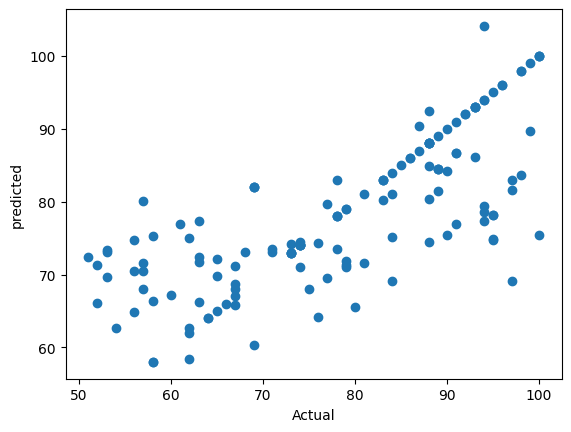

In [30]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('predicted')

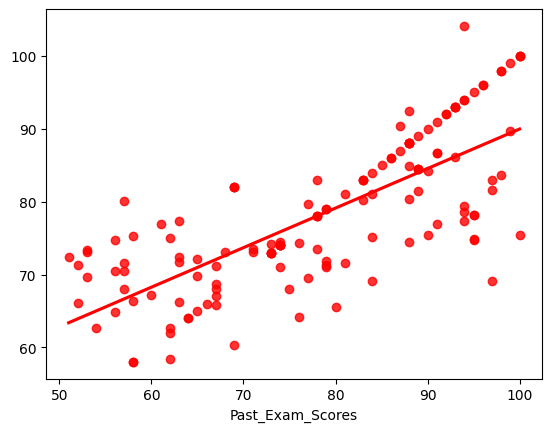

In [32]:
sns.regplot(x=y_test,y=y_pred,ci=None,color = 'red');

Difference between Actual and Predicted Values

In [33]:
pred_df=pd.DataFrame({'Actual Value': y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
294,89,84.438175,4.561825
256,65,72.167985,-7.167985
702,76,74.305887,1.694113
357,96,95.999763,0.000237
248,73,73.000311,-0.000311
...,...,...,...
439,94,104.132248,-10.132248
41,67,65.882836,1.117164
108,54,62.637924,-8.637924
259,99,99.000958,-0.000958
